# The Problem: LLMs Can't Do Multi-Table Analytics

Consider this realistic scenario:

You have three CSV files:
- `weather.csv` - Daily temperature, humidity readings by station
- `stations.csv` - Station metadata (location, elevation, type)
- `population.csv` - Population data by region

A user asks:
> "Which station had the highest 7-day average temperature last month in highly populated areas?"

**LLMs consistently fail at:**
- Joining tables correctly on shared keys
- Aggregating with proper grouping
- Maintaining numerical precision
- Chaining multiple operations

## The Solution: Function-First Approach

Instead of asking LLMs to compute, we train them to **decide what operations to perform**:

```
User Query → LLM → [join, filter, rolling_mean, top_k] → Execute → Result
```

The LLM becomes an **operation planner**, not a calculator.

## Why FunctionGemma?

- **Tiny**: 270M parameters (runs on mobile)
- **Fast**: ~50 tokens/sec
- **Efficient**: 550MB RAM
- **Designed for function calling**: Native support for tool use

# Setup

In [1]:
# Install/fix dependencies (uses uv pip for speed!)
import subprocess
import sys
import os

def get_pip_cmd():
    """Get the fastest pip command available (prefer uv)."""
    try:
        subprocess.run(["uv", "--version"], check=True, capture_output=True)
        return ["uv", "pip", "install"]
    except:
        return [sys.executable, "-m", "pip", "install"]

def check_all_imports_work():
    """Check if all imports work correctly."""
    try:
        from unsloth import FastLanguageModel
        from trl import SFTTrainer
        from peft import LoraConfig
        import transformers
        return True
    except Exception as e:
        print(f"Import check failed: {type(e).__name__}: {e}")
        return False

# First try importing - if everything works, skip installation
if check_all_imports_work():
    print("All packages already installed and working!")
else:
    print("Fixing package versions...")
    pip_cmd = get_pip_cmd()
    print(f"Using: {' '.join(pip_cmd)}")
    
    in_colab = "COLAB_" in "".join(os.environ.keys())
    
    if in_colab:
        import torch
        import re
        v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
        xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
        subprocess.run(pip_cmd + ["--no-deps", 
                      "bitsandbytes", "accelerate", xformers, 
                      "triton", "cut_cross_entropy", "unsloth_zoo"], check=True)
        subprocess.run(pip_cmd + [
                      "sentencepiece", "protobuf", "datasets>=2.16.0", 
                      "huggingface_hub>=0.34.0", "hf_transfer"], check=True)
    
    # Install compatible versions - order matters!
    # These versions are known to work together
    subprocess.run(pip_cmd + ["transformers==4.46.3"], check=True)
    subprocess.run(pip_cmd + ["peft==0.13.2"], check=True)
    subprocess.run(pip_cmd + ["trl==0.12.2"], check=True)
    subprocess.run(pip_cmd + ["unsloth"], check=True)
    
    print("\n" + "="*60)
    print("Installation complete! Please RESTART THE KERNEL and run again.")
    print("="*60)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/nipun.batra/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unsloth: Your Flash Attention 2 installation seems to be broken?
A possible explanation is you have a new CUDA version which isn't
yet compatible with FA2? Please file a ticket to Unsloth or FA2.
We shall now use Xformers instead, which does not have any performance hits!
We found this negligible impact by benchmarking on 1x A100.
🦥 Unsloth Zoo will now patch everything to make training faster!
All packages already installed and working!


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
from pathlib import Path
from typing import Dict, List, Any, Optional, Union
import warnings
warnings.filterwarnings('ignore')

# Create data directory
Path("data").mkdir(exist_ok=True)

print("Setup complete")

Setup complete


# Step 1: Create Realistic Multi-Table Datasets

We'll create interconnected datasets that require joins and aggregations.

In [3]:
np.random.seed(42)

# === STATIONS TABLE ===
# 20 weather stations across different regions
stations = pd.DataFrame({
    'station_id': [f'ST{i:03d}' for i in range(1, 21)],
    'station_name': [
        'Downtown Metro', 'Airport Terminal', 'Harbor Point', 'Mountain View', 'Valley Center',
        'Industrial Zone', 'University Campus', 'Shopping District', 'Residential North', 'Residential South',
        'Tech Park', 'Medical Center', 'Sports Complex', 'Beach Front', 'Forest Reserve',
        'Agricultural Hub', 'Transit Station', 'Power Plant', 'Water Treatment', 'City Hall'
    ],
    'region': ['Urban']*6 + ['Suburban']*7 + ['Coastal']*3 + ['Rural']*4,
    'elevation_m': np.random.randint(10, 500, 20),
    'station_type': np.random.choice(['Primary', 'Secondary', 'Backup'], 20, p=[0.4, 0.4, 0.2]),
    'install_year': np.random.randint(2010, 2024, 20)
})

stations.to_csv('data/stations.csv', index=False)
print(f"Created stations.csv: {len(stations)} stations")
stations.head()

Created stations.csv: 20 stations


,station_id,station_name,region,elevation_m,station_type,install_year
0,ST001,Downtown Metro,Urban,112,Primary,2012
1,ST002,Airport Terminal,Urban,445,Backup,2016
2,ST003,Harbor Point,Urban,358,Backup,2014
3,ST004,Mountain View,Urban,280,Primary,2018
4,ST005,Valley Center,Urban,116,Primary,2016


In [4]:
# === POPULATION TABLE ===
# Population data by region with demographics
population = pd.DataFrame({
    'region': ['Urban', 'Suburban', 'Coastal', 'Rural'],
    'population': [850000, 420000, 180000, 95000],
    'density_per_km2': [12500, 3200, 1800, 45],
    'median_income': [75000, 92000, 88000, 52000],
    'avg_household_size': [2.1, 3.2, 2.8, 3.5]
})

population.to_csv('data/population.csv', index=False)
print(f"Created population.csv: {len(population)} regions")
population

Created population.csv: 4 regions


,region,population,density_per_km2,median_income,avg_household_size
0,Urban,850000,12500,75000,2.1
1,Suburban,420000,3200,92000,3.2
2,Coastal,180000,1800,88000,2.8
3,Rural,95000,45,52000,3.5


In [5]:
# === WEATHER TABLE ===
# 90 days of weather data for all stations
dates = pd.date_range(start='2024-10-01', periods=90, freq='D')
station_ids = stations['station_id'].tolist()

weather_records = []
for station_id in station_ids:
    # Base temperature varies by station (some are warmer/cooler)
    base_temp = np.random.uniform(15, 25)
    for date in dates:
        # Seasonal variation + daily noise
        day_of_year = date.timetuple().tm_yday
        seasonal = 10 * np.sin(2 * np.pi * (day_of_year - 80) / 365)
        temp = base_temp + seasonal + np.random.normal(0, 3)
        
        weather_records.append({
            'station_id': station_id,
            'date': date.strftime('%Y-%m-%d'),
            'temperature_c': round(temp, 1),
            'humidity_pct': round(np.random.uniform(30, 90), 1),
            'wind_speed_kmh': round(np.random.uniform(0, 40), 1),
            'precipitation_mm': round(max(0, np.random.exponential(5) - 3), 1),
            'air_quality_index': np.random.randint(20, 150)
        })

weather = pd.DataFrame(weather_records)
weather.to_csv('data/weather.csv', index=False)
print(f"Created weather.csv: {len(weather)} records ({len(station_ids)} stations × {len(dates)} days)")
weather.head(10)

Created weather.csv: 1800 records (20 stations × 90 days)


,station_id,date,temperature_c,humidity_pct,wind_speed_kmh,precipitation_mm,air_quality_index
0,ST001,2024-10-01,17.9,53.5,7.3,4.0,73
1,ST001,2024-10-02,19.9,62.8,7.4,14.5,63
2,ST001,2024-10-03,20.8,35.3,7.8,0.0,59
3,ST001,2024-10-04,19.0,80.7,29.9,0.9,43
4,ST001,2024-10-05,14.3,62.6,5.6,5.1,84
5,ST001,2024-10-06,15.5,30.9,16.9,0.0,82
6,ST001,2024-10-07,19.7,73.7,30.9,0.0,60
7,ST001,2024-10-08,20.5,84.9,34.0,0.0,52
8,ST001,2024-10-09,17.1,49.5,29.2,2.1,54
9,ST001,2024-10-10,16.3,58.3,4.8,3.2,20


In [6]:
# === ALERTS TABLE ===
# Historical weather alerts
n_alerts = 50
alerts = pd.DataFrame({
    'alert_id': range(1, n_alerts + 1),
    'station_id': np.random.choice(station_ids, n_alerts),
    'date': np.random.choice(dates, n_alerts),
    'alert_type': np.random.choice(['Heat Wave', 'Storm', 'Fog', 'High Wind', 'Poor Air Quality'], n_alerts),
    'severity': np.random.choice(['Low', 'Medium', 'High', 'Critical'], n_alerts, p=[0.3, 0.4, 0.2, 0.1])
})
alerts['date'] = pd.to_datetime(alerts['date']).dt.strftime('%Y-%m-%d')

alerts.to_csv('data/alerts.csv', index=False)
print(f"Created alerts.csv: {len(alerts)} alerts")
alerts.head()

Created alerts.csv: 50 alerts


,alert_id,station_id,date,alert_type,severity
0,1,ST010,2024-12-15,Storm,Medium
1,2,ST005,2024-10-09,Fog,Medium
2,3,ST018,2024-12-07,Poor Air Quality,Medium
3,4,ST015,2024-11-08,Fog,Medium
4,5,ST020,2024-10-24,Poor Air Quality,Low


In [7]:
# Load all datasets into a registry
DATASETS = {
    'weather': pd.read_csv('data/weather.csv'),
    'stations': pd.read_csv('data/stations.csv'),
    'population': pd.read_csv('data/population.csv'),
    'alerts': pd.read_csv('data/alerts.csv')
}

print("\nDataset Schema:")
print("="*60)
for name, df in DATASETS.items():
    print(f"\n{name}: {len(df)} rows")
    print(f"  Columns: {', '.join(df.columns)}")


Dataset Schema:

weather: 1800 rows
  Columns: station_id, date, temperature_c, humidity_pct, wind_speed_kmh, precipitation_mm, air_quality_index

stations: 20 rows
  Columns: station_id, station_name, region, elevation_m, station_type, install_year

population: 4 rows
  Columns: region, population, density_per_km2, median_income, avg_household_size

alerts: 50 rows
  Columns: alert_id, station_id, date, alert_type, severity


# Step 2: Define Typed Data Operation Functions

These are the building blocks the LLM will learn to compose.

In [8]:
# Global state for chained operations
CURRENT_DF = None

def load_table(table: str) -> str:
    """Load a table into the working state.
    
    Args:
        table: Table name ('weather', 'stations', 'population', 'alerts')
    Returns:
        Status message with row count
    """
    global CURRENT_DF
    if table not in DATASETS:
        return f"Error: Table '{table}' not found. Available: {list(DATASETS.keys())}"
    CURRENT_DF = DATASETS[table].copy()
    return f"Loaded {table}: {len(CURRENT_DF)} rows"


def join_table(right_table: str, on: str, how: str = 'inner') -> str:
    """Join current table with another table.
    
    Args:
        right_table: Table to join with ('weather', 'stations', 'population', 'alerts')
        on: Column name to join on (e.g., 'station_id', 'region')
        how: Join type ('inner', 'left', 'right', 'outer')
    Returns:
        Status message with row count
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded. Use load_table first."
    if right_table not in DATASETS:
        return f"Error: Table '{right_table}' not found."
    
    right_df = DATASETS[right_table].copy()
    CURRENT_DF = CURRENT_DF.merge(right_df, on=on, how=how)
    return f"Joined with {right_table} on '{on}': {len(CURRENT_DF)} rows"


def filter_rows(column: str, operator: str, value: Union[str, int, float]) -> str:
    """Filter rows based on a condition.
    
    Args:
        column: Column name to filter on
        operator: Comparison operator ('==', '!=', '>', '<', '>=', '<=', 'contains', 'in')
        value: Value to compare against (use list for 'in' operator)
    Returns:
        Status message with row count
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    
    before = len(CURRENT_DF)
    if operator == '==':
        CURRENT_DF = CURRENT_DF[CURRENT_DF[column] == value]
    elif operator == '!=':
        CURRENT_DF = CURRENT_DF[CURRENT_DF[column] != value]
    elif operator == '>':
        CURRENT_DF = CURRENT_DF[CURRENT_DF[column] > value]
    elif operator == '<':
        CURRENT_DF = CURRENT_DF[CURRENT_DF[column] < value]
    elif operator == '>=':
        CURRENT_DF = CURRENT_DF[CURRENT_DF[column] >= value]
    elif operator == '<=':
        CURRENT_DF = CURRENT_DF[CURRENT_DF[column] <= value]
    elif operator == 'contains':
        CURRENT_DF = CURRENT_DF[CURRENT_DF[column].str.contains(value, case=False, na=False)]
    elif operator == 'in':
        CURRENT_DF = CURRENT_DF[CURRENT_DF[column].isin(value)]
    
    return f"Filtered {column} {operator} {value}: {before} → {len(CURRENT_DF)} rows"


def filter_date_range(column: str, start_date: str, end_date: str) -> str:
    """Filter rows within a date range.
    
    Args:
        column: Date column name
        start_date: Start date (YYYY-MM-DD)
        end_date: End date (YYYY-MM-DD)
    Returns:
        Status message with row count
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    
    before = len(CURRENT_DF)
    CURRENT_DF[column] = pd.to_datetime(CURRENT_DF[column])
    CURRENT_DF = CURRENT_DF[
        (CURRENT_DF[column] >= start_date) & 
        (CURRENT_DF[column] <= end_date)
    ]
    return f"Filtered {column} from {start_date} to {end_date}: {before} → {len(CURRENT_DF)} rows"


def aggregate(group_by: List[str], aggregations: Dict[str, str]) -> str:
    """Aggregate data with grouping.
    
    Args:
        group_by: List of columns to group by (e.g., ['station_id'], ['region', 'station_type'])
        aggregations: Dict mapping column to aggregation function
                     (e.g., {'temperature_c': 'mean', 'precipitation_mm': 'sum'})
                     Functions: 'mean', 'sum', 'min', 'max', 'count', 'std'
    Returns:
        Status message with row count
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    
    CURRENT_DF = CURRENT_DF.groupby(group_by).agg(aggregations).reset_index()
    # Flatten column names if multi-level
    if isinstance(CURRENT_DF.columns, pd.MultiIndex):
        CURRENT_DF.columns = ['_'.join(col).strip('_') for col in CURRENT_DF.columns]
    return f"Aggregated by {group_by}: {len(CURRENT_DF)} groups"


def rolling_window(column: str, window: int, function: str, group_by: str = None) -> str:
    """Apply rolling window calculation.
    
    Args:
        column: Column to calculate rolling value on
        window: Window size in rows (e.g., 7 for 7-day)
        function: Rolling function ('mean', 'sum', 'min', 'max', 'std')
        group_by: Optional column to group by before rolling (e.g., 'station_id')
    Returns:
        Status message
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    
    new_col = f"{column}_rolling_{window}_{function}"
    
    if group_by:
        CURRENT_DF = CURRENT_DF.sort_values([group_by, 'date'])
        CURRENT_DF[new_col] = CURRENT_DF.groupby(group_by)[column].transform(
            lambda x: getattr(x.rolling(window, min_periods=1), function)()
        )
    else:
        CURRENT_DF[new_col] = getattr(CURRENT_DF[column].rolling(window, min_periods=1), function)()
    
    return f"Added {new_col}"


def sort_values(column: str, ascending: bool = True) -> str:
    """Sort the current table.
    
    Args:
        column: Column to sort by
        ascending: Sort ascending (True) or descending (False)
    Returns:
        Status message
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    
    CURRENT_DF = CURRENT_DF.sort_values(column, ascending=ascending)
    return f"Sorted by {column} ({'ascending' if ascending else 'descending'})"


def top_k(k: int, column: str = None) -> str:
    """Get top K rows (assumes already sorted or specify column).
    
    Args:
        k: Number of rows to return
        column: Optional column to sort by (descending) before taking top K
    Returns:
        JSON string of top K results
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    
    if column:
        CURRENT_DF = CURRENT_DF.nlargest(k, column)
    else:
        CURRENT_DF = CURRENT_DF.head(k)
    
    return CURRENT_DF.to_json(orient='records', date_format='iso')


def bottom_k(k: int, column: str = None) -> str:
    """Get bottom K rows.
    
    Args:
        k: Number of rows to return
        column: Optional column to sort by (ascending) before taking bottom K
    Returns:
        JSON string of bottom K results
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    
    if column:
        CURRENT_DF = CURRENT_DF.nsmallest(k, column)
    else:
        CURRENT_DF = CURRENT_DF.tail(k)
    
    return CURRENT_DF.to_json(orient='records', date_format='iso')


def count_rows() -> str:
    """Count rows in current table.
    
    Returns:
        Row count as string
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    return str(len(CURRENT_DF))


def get_value(column: str, aggregation: str = 'first') -> str:
    """Get a single value from the current table.
    
    Args:
        column: Column to get value from
        aggregation: How to aggregate if multiple rows ('first', 'last', 'mean', 'sum', 'min', 'max')
    Returns:
        The value as string
    """
    global CURRENT_DF
    if CURRENT_DF is None:
        return "Error: No table loaded."
    
    if aggregation == 'first':
        val = CURRENT_DF[column].iloc[0]
    elif aggregation == 'last':
        val = CURRENT_DF[column].iloc[-1]
    elif aggregation == 'mean':
        val = CURRENT_DF[column].mean()
    elif aggregation == 'sum':
        val = CURRENT_DF[column].sum()
    elif aggregation == 'min':
        val = CURRENT_DF[column].min()
    elif aggregation == 'max':
        val = CURRENT_DF[column].max()
    
    return str(round(val, 2) if isinstance(val, float) else val)


# Function registry
FUNCTIONS = {
    'load_table': load_table,
    'join_table': join_table,
    'filter_rows': filter_rows,
    'filter_date_range': filter_date_range,
    'aggregate': aggregate,
    'rolling_window': rolling_window,
    'sort_values': sort_values,
    'top_k': top_k,
    'bottom_k': bottom_k,
    'count_rows': count_rows,
    'get_value': get_value,
}

print(f"Defined {len(FUNCTIONS)} data operation functions:")
for name in FUNCTIONS:
    print(f"  • {name}")

Defined 11 data operation functions:
  • load_table
  • join_table
  • filter_rows
  • filter_date_range
  • aggregate
  • rolling_window
  • sort_values
  • top_k
  • bottom_k
  • count_rows
  • get_value


In [9]:
# Test the functions with a complex query
print("Example: Find the hottest station in Urban areas last month")
print("="*60)

# Reset state
CURRENT_DF = None

# Execute sequence of operations
print(load_table('weather'))
print(join_table('stations', on='station_id'))
print(join_table('population', on='region'))
print(filter_rows('region', '==', 'Urban'))
print(filter_date_range('date', '2024-11-01', '2024-11-30'))
print(aggregate(['station_id', 'station_name'], {'temperature_c': 'mean'}))
result = top_k(3, 'temperature_c')
print(f"\nTop 3 hottest Urban stations in November:")
print(json.dumps(json.loads(result), indent=2))

Example: Find the hottest station in Urban areas last month
Loaded weather: 1800 rows
Joined with stations on 'station_id': 1800 rows
Joined with population on 'region': 1800 rows
Filtered region == Urban: 1800 → 540 rows
Filtered date from 2024-11-01 to 2024-11-30: 540 → 180 rows
Aggregated by ['station_id', 'station_name']: 6 groups

Top 3 hottest Urban stations in November:
[
  {
    "station_id": "ST002",
    "station_name": "Airport Terminal",
    "temperature_c": 13.2966666667
  },
  {
    "station_id": "ST001",
    "station_name": "Downtown Metro",
    "temperature_c": 12.9033333333
  },
  {
    "station_id": "ST003",
    "station_name": "Harbor Point",
    "temperature_c": 11.6166666667
  }
]


# Step 3: Create Training Dataset

Generate query → function sequence pairs for training.

In [10]:
# Training examples: (query, list of function calls)
training_examples = [
    # === Simple single-table queries ===
    {
        "query": "How many weather stations do we have?",
        "calls": [
            {"function": "load_table", "args": {"table": "stations"}},
            {"function": "count_rows", "args": {}}
        ]
    },
    {
        "query": "List all Primary type stations",
        "calls": [
            {"function": "load_table", "args": {"table": "stations"}},
            {"function": "filter_rows", "args": {"column": "station_type", "operator": "==", "value": "Primary"}},
            {"function": "top_k", "args": {"k": 100}}
        ]
    },
    {
        "query": "What is the population of the Urban region?",
        "calls": [
            {"function": "load_table", "args": {"table": "population"}},
            {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Urban"}},
            {"function": "get_value", "args": {"column": "population", "aggregation": "first"}}
        ]
    },
    {
        "query": "Show the 5 oldest weather stations",
        "calls": [
            {"function": "load_table", "args": {"table": "stations"}},
            {"function": "bottom_k", "args": {"k": 5, "column": "install_year"}}
        ]
    },
    {
        "query": "Count weather readings from October 2024",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "filter_date_range", "args": {"column": "date", "start_date": "2024-10-01", "end_date": "2024-10-31"}},
            {"function": "count_rows", "args": {}}
        ]
    },
    
    # === Two-table joins ===
    {
        "query": "What is the average temperature by region?",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "aggregate", "args": {"group_by": ["region"], "aggregations": {"temperature_c": "mean"}}},
            {"function": "top_k", "args": {"k": 10}}
        ]
    },
    {
        "query": "Which stations in Suburban areas have the most alerts?",
        "calls": [
            {"function": "load_table", "args": {"table": "alerts"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Suburban"}},
            {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"alert_id": "count"}}},
            {"function": "top_k", "args": {"k": 5, "column": "alert_id"}}
        ]
    },
    {
        "query": "Find the coldest station overall",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"temperature_c": "mean"}}},
            {"function": "bottom_k", "args": {"k": 1, "column": "temperature_c"}}
        ]
    },
    {
        "query": "How many Critical severity alerts occurred?",
        "calls": [
            {"function": "load_table", "args": {"table": "alerts"}},
            {"function": "filter_rows", "args": {"column": "severity", "operator": "==", "value": "Critical"}},
            {"function": "count_rows", "args": {}}
        ]
    },
    {
        "query": "What's the total precipitation by station type?",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "aggregate", "args": {"group_by": ["station_type"], "aggregations": {"precipitation_mm": "sum"}}},
            {"function": "top_k", "args": {"k": 10}}
        ]
    },
    
    # === Three-table joins ===
    {
        "query": "Which stations in high population areas have the worst air quality?",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "join_table", "args": {"right_table": "population", "on": "region"}},
            {"function": "filter_rows", "args": {"column": "population", "operator": ">", "value": 400000}},
            {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"air_quality_index": "mean"}}},
            {"function": "top_k", "args": {"k": 5, "column": "air_quality_index"}}
        ]
    },
    {
        "query": "Average temperature in Urban areas in November",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Urban"}},
            {"function": "filter_date_range", "args": {"column": "date", "start_date": "2024-11-01", "end_date": "2024-11-30"}},
            {"function": "get_value", "args": {"column": "temperature_c", "aggregation": "mean"}}
        ]
    },
    {
        "query": "Find the hottest station in Coastal region last week",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Coastal"}},
            {"function": "filter_date_range", "args": {"column": "date", "start_date": "2024-12-17", "end_date": "2024-12-24"}},
            {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"temperature_c": "mean"}}},
            {"function": "top_k", "args": {"k": 1, "column": "temperature_c"}}
        ]
    },
    
    # === Rolling window queries ===
    {
        "query": "What's the 7-day average temperature trend for station ST001?",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "filter_rows", "args": {"column": "station_id", "operator": "==", "value": "ST001"}},
            {"function": "rolling_window", "args": {"column": "temperature_c", "window": 7, "function": "mean"}},
            {"function": "top_k", "args": {"k": 30}}
        ]
    },
    {
        "query": "Calculate 3-day rolling max temperature by station",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "rolling_window", "args": {"column": "temperature_c", "window": 3, "function": "max", "group_by": "station_id"}},
            {"function": "top_k", "args": {"k": 50}}
        ]
    },
    {
        "query": "Which station had the highest 7-day average temperature in November in highly populated areas?",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "join_table", "args": {"right_table": "population", "on": "region"}},
            {"function": "filter_rows", "args": {"column": "population", "operator": ">", "value": 400000}},
            {"function": "filter_date_range", "args": {"column": "date", "start_date": "2024-11-01", "end_date": "2024-11-30"}},
            {"function": "rolling_window", "args": {"column": "temperature_c", "window": 7, "function": "mean", "group_by": "station_id"}},
            {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"temperature_c_rolling_7_mean": "max"}}},
            {"function": "top_k", "args": {"k": 1, "column": "temperature_c_rolling_7_mean"}}
        ]
    },
    
    # === More filter variations ===
    {
        "query": "Find days with temperature above 30 degrees",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "filter_rows", "args": {"column": "temperature_c", "operator": ">", "value": 30}},
            {"function": "top_k", "args": {"k": 50}}
        ]
    },
    {
        "query": "Stations at elevation above 300 meters",
        "calls": [
            {"function": "load_table", "args": {"table": "stations"}},
            {"function": "filter_rows", "args": {"column": "elevation_m", "operator": ">", "value": 300}},
            {"function": "top_k", "args": {"k": 20}}
        ]
    },
    {
        "query": "Low humidity days (below 40%) count",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "filter_rows", "args": {"column": "humidity_pct", "operator": "<", "value": 40}},
            {"function": "count_rows", "args": {}}
        ]
    },
    
    # === Complex multi-step queries ===
    {
        "query": "Which region has the most weather alerts per capita?",
        "calls": [
            {"function": "load_table", "args": {"table": "alerts"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "aggregate", "args": {"group_by": ["region"], "aggregations": {"alert_id": "count"}}},
            {"function": "join_table", "args": {"right_table": "population", "on": "region"}},
            {"function": "top_k", "args": {"k": 10}}
        ]
    },
    {
        "query": "Average wind speed for stations installed after 2020",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "filter_rows", "args": {"column": "install_year", "operator": ">", "value": 2020}},
            {"function": "get_value", "args": {"column": "wind_speed_kmh", "aggregation": "mean"}}
        ]
    },
    {
        "query": "Heat Wave alerts in Rural areas",
        "calls": [
            {"function": "load_table", "args": {"table": "alerts"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Rural"}},
            {"function": "filter_rows", "args": {"column": "alert_type", "operator": "==", "value": "Heat Wave"}},
            {"function": "count_rows", "args": {}}
        ]
    },
    {
        "query": "Highest precipitation day in December",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "filter_date_range", "args": {"column": "date", "start_date": "2024-12-01", "end_date": "2024-12-31"}},
            {"function": "top_k", "args": {"k": 1, "column": "precipitation_mm"}}
        ]
    },
    {
        "query": "Compare average temperature between Urban and Rural regions",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "filter_rows", "args": {"column": "region", "operator": "in", "value": ["Urban", "Rural"]}},
            {"function": "aggregate", "args": {"group_by": ["region"], "aggregations": {"temperature_c": "mean"}}},
            {"function": "top_k", "args": {"k": 10}}
        ]
    },
    {
        "query": "Station with most consistent temperature (lowest std dev)",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"temperature_c": "std"}}},
            {"function": "bottom_k", "args": {"k": 1, "column": "temperature_c"}}
        ]
    },
    {
        "query": "Median income of regions with temperature above 25 degrees on average",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "aggregate", "args": {"group_by": ["region"], "aggregations": {"temperature_c": "mean"}}},
            {"function": "filter_rows", "args": {"column": "temperature_c", "operator": ">", "value": 25}},
            {"function": "join_table", "args": {"right_table": "population", "on": "region"}},
            {"function": "top_k", "args": {"k": 10}}
        ]
    },
    
    # === More examples for better coverage ===
    {
        "query": "List all stations in the Urban region",
        "calls": [
            {"function": "load_table", "args": {"table": "stations"}},
            {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Urban"}},
            {"function": "top_k", "args": {"k": 50}}
        ]
    },
    {
        "query": "Total rainfall in Suburban areas",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Suburban"}},
            {"function": "get_value", "args": {"column": "precipitation_mm", "aggregation": "sum"}}
        ]
    },
    {
        "query": "Most recent weather reading for each station",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "sort_values", "args": {"column": "date", "ascending": False}},
            {"function": "aggregate", "args": {"group_by": ["station_id"], "aggregations": {"date": "first", "temperature_c": "first"}}},
            {"function": "top_k", "args": {"k": 20}}
        ]
    },
    {
        "query": "Average air quality by region",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
            {"function": "aggregate", "args": {"group_by": ["region"], "aggregations": {"air_quality_index": "mean"}}},
            {"function": "top_k", "args": {"k": 10}}
        ]
    },
    {
        "query": "Storm alerts count by station",
        "calls": [
            {"function": "load_table", "args": {"table": "alerts"}},
            {"function": "filter_rows", "args": {"column": "alert_type", "operator": "==", "value": "Storm"}},
            {"function": "aggregate", "args": {"group_by": ["station_id"], "aggregations": {"alert_id": "count"}}},
            {"function": "top_k", "args": {"k": 20, "column": "alert_id"}}
        ]
    },
    {
        "query": "Windiest day on record",
        "calls": [
            {"function": "load_table", "args": {"table": "weather"}},
            {"function": "top_k", "args": {"k": 1, "column": "wind_speed_kmh"}}
        ]
    },
]

print(f"Created {len(training_examples)} training examples")
print(f"\nSample:")
print(json.dumps(training_examples[15], indent=2))  # The complex 7-day average query

Created 32 training examples

Sample:
{
  "query": "Which station had the highest 7-day average temperature in November in highly populated areas?",
  "calls": [
    {
      "function": "load_table",
      "args": {
        "table": "weather"
      }
    },
    {
      "function": "join_table",
      "args": {
        "right_table": "stations",
        "on": "station_id"
      }
    },
    {
      "function": "join_table",
      "args": {
        "right_table": "population",
        "on": "region"
      }
    },
    {
      "function": "filter_rows",
      "args": {
        "column": "population",
        "operator": ">",
        "value": 400000
      }
    },
    {
      "function": "filter_date_range",
      "args": {
        "column": "date",
        "start_date": "2024-11-01",
        "end_date": "2024-11-30"
      }
    },
    {
      "function": "rolling_window",
      "args": {
        "column": "temperature_c",
        "window": 7,
        "function": "mean",
        "group_by"

In [11]:
# Convert to FunctionGemma format
SYSTEM_PROMPT = """You are a data analysis assistant. You have access to these tables:
- weather: station_id, date, temperature_c, humidity_pct, wind_speed_kmh, precipitation_mm, air_quality_index
- stations: station_id, station_name, region, elevation_m, station_type, install_year
- population: region, population, density_per_km2, median_income, avg_household_size
- alerts: alert_id, station_id, date, alert_type, severity

Call functions to answer queries. Available functions:
- load_table(table) - Load a table
- join_table(right_table, on, how='inner') - Join with another table
- filter_rows(column, operator, value) - Filter rows (operators: ==, !=, >, <, >=, <=, in, contains)
- filter_date_range(column, start_date, end_date) - Filter by date range
- aggregate(group_by, aggregations) - Group and aggregate
- rolling_window(column, window, function, group_by) - Rolling calculations
- sort_values(column, ascending) - Sort
- top_k(k, column) - Get top K rows
- bottom_k(k, column) - Get bottom K rows
- count_rows() - Count rows
- get_value(column, aggregation) - Get single value

Respond with function calls in sequence using this format:
<function_calls>
[{"function": "name", "args": {...}}, ...]
</function_calls>"""

def create_training_prompt(example):
    """Create training prompt in chat format."""
    calls_json = json.dumps(example['calls'])
    
    prompt = f"""<start_of_turn>system
{SYSTEM_PROMPT}<end_of_turn>
<start_of_turn>user
{example['query']}<end_of_turn>
<start_of_turn>model
<function_calls>
{calls_json}
</function_calls><end_of_turn>"""
    
    return {"text": prompt}

# Create dataset
from datasets import Dataset
train_data = [create_training_prompt(ex) for ex in training_examples]
train_dataset = Dataset.from_list(train_data)

print(f"Training dataset: {len(train_dataset)} examples")
print("\nSample prompt:")
print(train_dataset[0]['text'][:800] + "...")

Training dataset: 32 examples

Sample prompt:
<start_of_turn>system
You are a data analysis assistant. You have access to these tables:
- weather: station_id, date, temperature_c, humidity_pct, wind_speed_kmh, precipitation_mm, air_quality_index
- stations: station_id, station_name, region, elevation_m, station_type, install_year
- population: region, population, density_per_km2, median_income, avg_household_size
- alerts: alert_id, station_id, date, alert_type, severity

Call functions to answer queries. Available functions:
- load_table(table) - Load a table
- join_table(right_table, on, how='inner') - Join with another table
- filter_rows(column, operator, value) - Filter rows (operators: ==, !=, >, <, >=, <=, in, contains)
- filter_date_range(column, start_date, end_date) - Filter by date range
- aggregate(group_by, aggregations) ...


# Step 4: Load FunctionGemma and Test Zero-Shot

In [12]:
from unsloth import FastLanguageModel

# Load base model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-2-2b-it",  # Using Gemma 2 2B for better performance
    max_seq_length=2048,
    load_in_4bit=True,
    dtype=None,
)

print(f"Loaded Gemma 2 2B model")

Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2025.12.9: Fast Gemma2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA RTX A4000. Num GPUs = 2. Max memory: 15.724 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loaded Gemma 2 2B model


In [13]:
# Test queries that require multi-step reasoning
test_queries = [
    "Which station had the highest 7-day average temperature in November in highly populated areas?",
    "What is the average temperature by region?",
    "Find stations in Urban areas with more than 3 alerts",
    "Coldest station in Coastal region",
    "Total precipitation in December by station type",
]

print("Test Queries:")
for i, q in enumerate(test_queries, 1):
    print(f"{i}. {q}")

Test Queries:
1. Which station had the highest 7-day average temperature in November in highly populated areas?
2. What is the average temperature by region?
3. Find stations in Urban areas with more than 3 alerts
4. Coldest station in Coastal region
5. Total precipitation in December by station type


In [14]:
def generate_response(model, tokenizer, query, max_new_tokens=512):
    """Generate model response for a query."""
    prompt = f"""<start_of_turn>system
{SYSTEM_PROMPT}<end_of_turn>
<start_of_turn>user
{query}<end_of_turn>
<start_of_turn>model
"""
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=False)
    # Extract just the model response
    if "<start_of_turn>model" in response:
        response = response.split("<start_of_turn>model")[-1]
    if "<end_of_turn>" in response:
        response = response.split("<end_of_turn>")[0]
    return response.strip()

print("Response function ready")

Response function ready


In [15]:
# Test zero-shot performance
FastLanguageModel.for_inference(model)

print("="*80)
print("ZERO-SHOT PERFORMANCE")
print("="*80)

zero_shot_results = []
for query in test_queries:
    print(f"\nQuery: {query}")
    print("-"*60)
    response = generate_response(model, tokenizer, query)
    print(f"Response:\n{response[:500]}..." if len(response) > 500 else f"Response:\n{response}")
    zero_shot_results.append({"query": query, "response": response})

ZERO-SHOT PERFORMANCE

Query: Which station had the highest 7-day average temperature in November in highly populated areas?
------------------------------------------------------------
Response:
```
load_table(weather)
load_table(stations)
load_table(population)
join_table(stations, stations.station_id, weather.station_id, how='inner')
filter_rows(weather.date, '>', '2023-11-01')
filter_rows(weather.date, '<', '2023-11-08')
filter_rows(stations.region, 'in', population.region)
aggregate(group_by=weather.station_id, aggregations='avg(temperature_c)')
sort_values(aggregations, ascending=True)
top_k(1, aggregations)
```

Query: What is the average temperature by region?
------------------------------------------------------------
Response:
```
load_table(weather)
load_table(stations)
aggregate(group_by=stations.region, aggregations=avg(temperature_c))
```

Query: Find stations in Urban areas with more than 3 alerts
------------------------------------------------------------
Response:
``

# Step 5: Fine-Tune the Model

In [16]:
from trl import SFTTrainer
from transformers import TrainingArguments

# Add LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

print("Added LoRA adapters")

Unsloth 2025.12.9 patched 26 layers with 26 QKV layers, 26 O layers and 26 MLP layers.


Added LoRA adapters


In [17]:
# Training configuration - more epochs for better learning
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    args=SFTConfig(
        output_dir="./gemma-multitable-finetuned",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=10,  # Increased from 5 to 10 for better learning
        learning_rate=2e-4,
        bf16=True,
        logging_steps=5,
        save_strategy="epoch",
        optim="adamw_8bit",
        warmup_steps=10,
        lr_scheduler_type="cosine",
        dataset_text_field="text",
        max_seq_length=1024,
        seed=42,
    ),
)

print(f"Training for 10 epochs (increased for better learning)")
print(f"Total steps: ~{len(train_dataset) * 10 // (2 * 4)}")

Unsloth: Tokenizing ["text"] (num_proc=20): 100%|██████████| 32/32 [00:13<00:00,  2.43 examples/s]

Training for 10 epochs (increased for better learning)
Total steps: ~40


In [18]:
# Train!
print("Starting fine-tuning...")
trainer.train()
print("\nFine-tuning complete!")

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting fine-tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 10 | Total steps = 40
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 20,766,720 of 2,635,108,608 (0.79% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,1.781000
10,1.048600
15,0.355600
20,0.156900
25,0.106400
30,0.088100
35,0.080300
40,0.076600



Fine-tuning complete!


# Step 6: Compare Zero-Shot vs Fine-Tuned

In [19]:
# Test fine-tuned model
FastLanguageModel.for_inference(model)

print("="*80)
print("FINE-TUNED PERFORMANCE")
print("="*80)

finetuned_results = []
for query in test_queries:
    print(f"\nQuery: {query}")
    print("-"*60)
    response = generate_response(model, tokenizer, query)
    print(f"Response:\n{response}")
    finetuned_results.append({"query": query, "response": response})

FINE-TUNED PERFORMANCE

Query: Which station had the highest 7-day average temperature in November in highly populated areas?
------------------------------------------------------------
Response:
<function_calls>
[{"function": "load_table", "args": {"table": "weather"}}, {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}}, {"function": "filter_rows", "args": {"column": "region", "operator": "in", "value": ["Urban", "Highly Urban"]}}, {"function": "filter_rows", "args": {"column": "date", "operator": "in", "value": ["2024-11-01", "2024-11-30"]}}, {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"temperature_c": "mean"}}}, {"function": "top_k", "args": {"k": 1, "column": "temperature_c"}}]
</function_calls>

Query: What is the average temperature by region?
------------------------------------------------------------
Response:
<function_calls>
[{"function": "load_table", "args": {"table": "weather"}}, {"funct

In [20]:
import re

def parse_function_calls(response):
    """Extract function calls from model response."""
    # Look for <function_calls>...</function_calls>
    match = re.search(r'<function_calls>\s*(.+?)\s*</function_calls>', response, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except:
            return None
    return None

def execute_calls(calls):
    """Execute a sequence of function calls."""
    global CURRENT_DF
    CURRENT_DF = None
    
    results = []
    for call in calls:
        func_name = call.get('function')
        args = call.get('args', {})
        
        if func_name in FUNCTIONS:
            try:
                result = FUNCTIONS[func_name](**args)
                results.append({"function": func_name, "result": result})
            except Exception as e:
                results.append({"function": func_name, "error": str(e)})
        else:
            results.append({"function": func_name, "error": "Unknown function"})
    
    return results

print("Execution utilities ready")

Execution utilities ready


In [21]:
# Ground truth function calls for test queries
ground_truth_calls = [
    # Query 1: "Which station had the highest 7-day average temperature in November in highly populated areas?"
    [
        {"function": "load_table", "args": {"table": "weather"}},
        {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
        {"function": "join_table", "args": {"right_table": "population", "on": "region"}},
        {"function": "filter_rows", "args": {"column": "population", "operator": ">", "value": 400000}},
        {"function": "filter_date_range", "args": {"column": "date", "start_date": "2024-11-01", "end_date": "2024-11-30"}},
        {"function": "rolling_window", "args": {"column": "temperature_c", "window": 7, "function": "mean", "group_by": "station_id"}},
        {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"temperature_c_rolling_7_mean": "max"}}},
        {"function": "top_k", "args": {"k": 1, "column": "temperature_c_rolling_7_mean"}}
    ],
    # Query 2: "What is the average temperature by region?"
    [
        {"function": "load_table", "args": {"table": "weather"}},
        {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
        {"function": "aggregate", "args": {"group_by": ["region"], "aggregations": {"temperature_c": "mean"}}},
        {"function": "top_k", "args": {"k": 10}}
    ],
    # Query 3: "Find stations in Urban areas with more than 3 alerts"
    [
        {"function": "load_table", "args": {"table": "alerts"}},
        {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
        {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Urban"}},
        {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"alert_id": "count"}}},
        {"function": "filter_rows", "args": {"column": "alert_id", "operator": ">", "value": 3}},
        {"function": "top_k", "args": {"k": 10}}
    ],
    # Query 4: "Coldest station in Coastal region"
    [
        {"function": "load_table", "args": {"table": "weather"}},
        {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
        {"function": "filter_rows", "args": {"column": "region", "operator": "==", "value": "Coastal"}},
        {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"temperature_c": "mean"}}},
        {"function": "bottom_k", "args": {"k": 1, "column": "temperature_c"}}
    ],
    # Query 5: "Total precipitation in December by station type"
    [
        {"function": "load_table", "args": {"table": "weather"}},
        {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
        {"function": "filter_date_range", "args": {"column": "date", "start_date": "2024-12-01", "end_date": "2024-12-31"}},
        {"function": "aggregate", "args": {"group_by": ["station_type"], "aggregations": {"precipitation_mm": "sum"}}},
        {"function": "top_k", "args": {"k": 10}}
    ],
]

# Execute ground truth and compare
print("="*80)
print("EXECUTION COMPARISON: Ground Truth vs Zero-Shot vs Fine-Tuned")
print("="*80)

comparison = []

for i, query in enumerate(test_queries):
    print(f"\n{'='*80}")
    print(f"Query {i+1}: {query}")
    print("="*80)
    
    # Execute Ground Truth
    print(f"\n[Ground Truth]")
    gt_result = execute_calls(ground_truth_calls[i])
    gt_final = gt_result[-1] if gt_result else None
    print(f"  Result: {str(gt_final)[:200]}...")
    
    # Parse and execute Zero-Shot
    zs_calls = parse_function_calls(zero_shot_results[i]['response'])
    print(f"\n[Zero-Shot] Parsed: {zs_calls is not None}")
    if zs_calls:
        zs_result = execute_calls(zs_calls)
        zs_final = zs_result[-1] if zs_result else None
        print(f"  Result: {str(zs_final)[:200]}...")
    else:
        zs_final = None
        print("  Could not parse function calls")
    
    # Parse and execute Fine-Tuned
    ft_calls = parse_function_calls(finetuned_results[i]['response'])
    print(f"\n[Fine-Tuned] Parsed: {ft_calls is not None}")
    if ft_calls:
        ft_result = execute_calls(ft_calls)
        ft_final = ft_result[-1] if ft_result else None
        print(f"  Result: {str(ft_final)[:200]}...")
    else:
        ft_final = None
        print("  Could not parse function calls")
    
    comparison.append({
        'query': query,
        'gt_success': gt_final is not None and 'error' not in gt_final,
        'zero_shot_parsed': zs_calls is not None,
        'zero_shot_success': zs_final is not None and 'error' not in str(zs_final),
        'finetuned_parsed': ft_calls is not None,
        'finetuned_success': ft_final is not None and 'error' not in str(ft_final),
    })

EXECUTION COMPARISON: Ground Truth vs Zero-Shot vs Fine-Tuned

Query 1: Which station had the highest 7-day average temperature in November in highly populated areas?

[Ground Truth]
  Result: {'function': 'top_k', 'result': '[{"station_id":"ST002","station_name":"Airport Terminal","temperature_c_rolling_7_mean":16.9857142857}]'}...

[Zero-Shot] Parsed: False
  Could not parse function calls

[Fine-Tuned] Parsed: True
  Result: {'function': 'top_k', 'result': '[{"station_id":"ST001","station_name":"Downtown Metro","temperature_c":14.2}]'}...

Query 2: What is the average temperature by region?

[Ground Truth]
  Result: {'function': 'top_k', 'result': '[{"region":"Coastal","temperature_c":11.1496296296},{"region":"Rural","temperature_c":15.3822222222},{"region":"Suburban","temperature_c":11.8588888889},{"region":"Urb...

[Zero-Shot] Parsed: False
  Could not parse function calls

[Fine-Tuned] Parsed: True
  Result: {'function': 'top_k', 'result': '[{"region":"Coastal","temperature_c":11


PERFORMANCE SUMMARY

Ground Truth Execution: 100.0%

Parsing Success Rate:
  Zero-Shot:  0.0%
  Fine-Tuned: 100.0%

Execution Success Rate:
  Zero-Shot:  0.0%
  Fine-Tuned: 80.0%


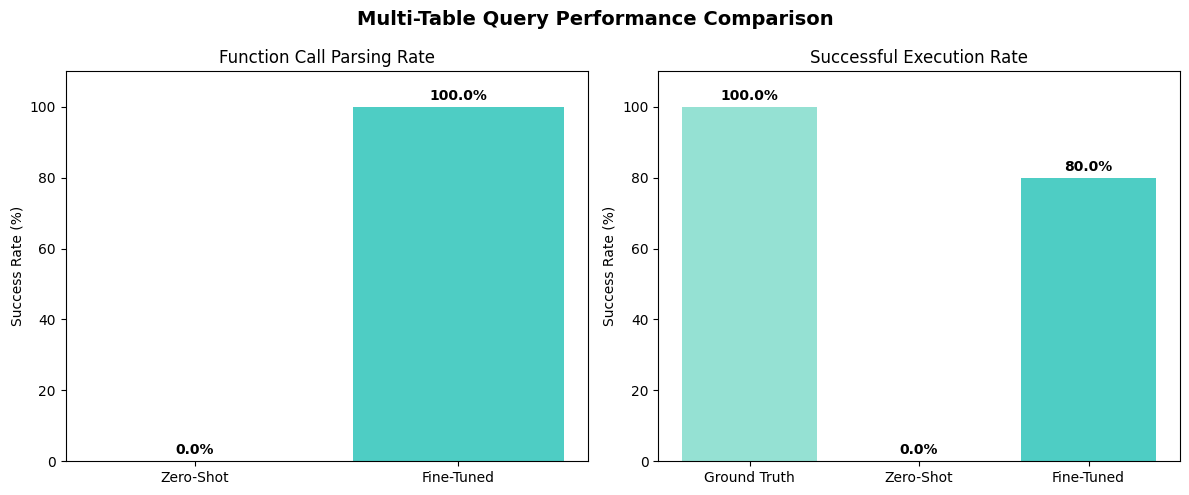


DETAILED RESULTS WITH ERROR ANALYSIS

--------------------------------------------------------------------------------
Q1: Which station had the highest 7-day average temperature in November in highly populated areas?
--------------------------------------------------------------------------------
Ground Truth: load_table -> join_table -> join_table -> filter_rows -> filter_date_range -> rolling_window -> aggregate -> top_k
Zero-Shot:    [FAIL] Could not parse (wrong format)
Fine-Tuned:   load_table -> join_table -> filter_rows -> filter_rows -> aggregate -> top_k
  Missing: {'filter_date_range', 'rolling_window'}

--------------------------------------------------------------------------------
Q2: What is the average temperature by region?
--------------------------------------------------------------------------------
Ground Truth: load_table -> join_table -> aggregate -> top_k
Zero-Shot:    [FAIL] Could not parse (wrong format)
Fine-Tuned:   load_table -> join_table -> aggregate ->

In [22]:
# Summary statistics with Ground Truth comparison
import matplotlib.pyplot as plt

df_comparison = pd.DataFrame(comparison)

zs_parse_rate = df_comparison['zero_shot_parsed'].mean() * 100
ft_parse_rate = df_comparison['finetuned_parsed'].mean() * 100
zs_exec_rate = df_comparison['zero_shot_success'].mean() * 100
ft_exec_rate = df_comparison['finetuned_success'].mean() * 100
gt_exec_rate = df_comparison['gt_success'].mean() * 100

print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)
print(f"\nGround Truth Execution: {gt_exec_rate:.1f}%")
print(f"\nParsing Success Rate:")
print(f"  Zero-Shot:  {zs_parse_rate:.1f}%")
print(f"  Fine-Tuned: {ft_parse_rate:.1f}%")
print(f"\nExecution Success Rate:")
print(f"  Zero-Shot:  {zs_exec_rate:.1f}%")
print(f"  Fine-Tuned: {ft_exec_rate:.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Parsing rate
axes[0].bar(['Zero-Shot', 'Fine-Tuned'], [zs_parse_rate, ft_parse_rate], 
            color=['#FF6B6B', '#4ECDC4'])
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_title('Function Call Parsing Rate')
axes[0].set_ylim(0, 110)
for i, v in enumerate([zs_parse_rate, ft_parse_rate]):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Execution rate (3-way comparison)
x_labels = ['Ground Truth', 'Zero-Shot', 'Fine-Tuned']
rates = [gt_exec_rate, zs_exec_rate, ft_exec_rate]
colors = ['#95E1D3', '#FF6B6B', '#4ECDC4']
bars = axes[1].bar(x_labels, rates, color=colors)
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_title('Successful Execution Rate')
axes[1].set_ylim(0, 110)
for i, v in enumerate(rates):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Multi-Table Query Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed results table with error analysis
print("\n" + "="*80)
print("DETAILED RESULTS WITH ERROR ANALYSIS")
print("="*80)

for i, query in enumerate(test_queries):
    print(f"\n{'-'*80}")
    print(f"Q{i+1}: {query}")
    print(f"{'-'*80}")
    
    # Ground truth info
    gt_funcs = [c['function'] for c in ground_truth_calls[i]]
    print(f"Ground Truth: {' -> '.join(gt_funcs)}")
    
    # Zero-shot
    zs_calls = parse_function_calls(zero_shot_results[i]['response'])
    if zs_calls:
        zs_funcs = [c['function'] for c in zs_calls]
        print(f"Zero-Shot:    {' -> '.join(zs_funcs)}")
    else:
        print(f"Zero-Shot:    [FAIL] Could not parse (wrong format)")
    
    # Fine-tuned
    ft_calls = parse_function_calls(finetuned_results[i]['response'])
    if ft_calls:
        ft_funcs = [c['function'] for c in ft_calls]
        print(f"Fine-Tuned:   {' -> '.join(ft_funcs)}")
        
        # Compare with ground truth
        missing = set(gt_funcs) - set(ft_funcs)
        if missing:
            print(f"  Missing: {missing}")
        
        # Check specific issues
        ft_result = execute_calls(ft_calls)
        if ft_result and 'error' in ft_result[-1]:
            print(f"  Error: {ft_result[-1]['error'][:60]}...")
    else:
        print(f"Fine-Tuned:   [FAIL] Could not parse")

# Step 7: Test the Complex Query

Let's test the original challenging query from our introduction.

In [23]:
# The challenge query - with detailed comparison
challenge = "Which station had the highest 7-day average temperature last month in highly populated areas?"

# Ground truth for this query
gt_calls = [
    {"function": "load_table", "args": {"table": "weather"}},
    {"function": "join_table", "args": {"right_table": "stations", "on": "station_id"}},
    {"function": "join_table", "args": {"right_table": "population", "on": "region"}},
    {"function": "filter_rows", "args": {"column": "population", "operator": ">", "value": 400000}},
    {"function": "filter_date_range", "args": {"column": "date", "start_date": "2024-11-01", "end_date": "2024-11-30"}},
    {"function": "rolling_window", "args": {"column": "temperature_c", "window": 7, "function": "mean", "group_by": "station_id"}},
    {"function": "aggregate", "args": {"group_by": ["station_id", "station_name"], "aggregations": {"temperature_c_rolling_7_mean": "max"}}},
    {"function": "top_k", "args": {"k": 1, "column": "temperature_c_rolling_7_mean"}}
]

print("="*80)
print("CHALLENGE QUERY ANALYSIS")
print("="*80)
print(f"\nQuery: {challenge}")

# Execute ground truth
print("\n" + "-"*40)
print("GROUND TRUTH EXECUTION:")
print("-"*40)
gt_result = execute_calls(gt_calls)
print(f"Steps: {len(gt_calls)}")
for i, call in enumerate(gt_calls):
    print(f"  {i+1}. {call['function']}({call['args']})")
print(f"\nResult: {gt_result[-1]}")

# Fine-tuned response
print("\n" + "-"*40)
print("FINE-TUNED MODEL RESPONSE:")
print("-"*40)
response = generate_response(model, tokenizer, challenge)
print(f"Raw response:\n{response}\n")

# Parse and execute
calls = parse_function_calls(response)
if calls:
    print(f"Parsed {len(calls)} function calls:")
    for i, call in enumerate(calls):
        print(f"  {i+1}. {call['function']}({call.get('args', {})})")
    
    print("\nExecution:")
    results = execute_calls(calls)
    for r in results:
        status = "[OK]" if 'result' in r else "[ERR]"
        print(f"  {status} {r['function']}: {str(r.get('result', r.get('error', '')))[:80]}...")
    
    print(f"\nFinal Result: {results[-1]}")
else:
    print("Could not parse function calls!")

# Analysis
print("\n" + "-"*40)
print("ANALYSIS - What the model got wrong:")
print("-"*40)
if calls:
    gt_funcs = [c['function'] for c in gt_calls]
    pred_funcs = [c['function'] for c in calls]
    
    # Check for missing functions
    missing = set(gt_funcs) - set(pred_funcs)
    extra = set(pred_funcs) - set(gt_funcs)
    
    if missing:
        print(f"  Missing functions: {missing}")
    if extra:
        print(f"  Extra/wrong functions: {extra}")
    
    # Check specific issues
    has_population_filter = any(
        c['function'] == 'filter_rows' and 
        c.get('args', {}).get('column') == 'population' 
        for c in calls
    )
    has_rolling = any(c['function'] == 'rolling_window' for c in calls)
    has_date_range = any(c['function'] == 'filter_date_range' for c in calls)
    
    if not has_population_filter:
        print("  [X] Missing: filter by population > 400000 (used literal 'Highly populated' instead)")
    if not has_rolling:
        print("  [X] Missing: rolling_window for 7-day average")
    if not has_date_range:
        print("  [X] Missing: filter_date_range for 'last month'")

CHALLENGE QUERY ANALYSIS

Query: Which station had the highest 7-day average temperature last month in highly populated areas?

----------------------------------------
GROUND TRUTH EXECUTION:
----------------------------------------
Steps: 8
  1. load_table({'table': 'weather'})
  2. join_table({'right_table': 'stations', 'on': 'station_id'})
  3. join_table({'right_table': 'population', 'on': 'region'})
  4. filter_rows({'column': 'population', 'operator': '>', 'value': 400000})
  5. filter_date_range({'column': 'date', 'start_date': '2024-11-01', 'end_date': '2024-11-30'})
  6. rolling_window({'column': 'temperature_c', 'window': 7, 'function': 'mean', 'group_by': 'station_id'})
  7. aggregate({'group_by': ['station_id', 'station_name'], 'aggregations': {'temperature_c_rolling_7_mean': 'max'}})
  8. top_k({'k': 1, 'column': 'temperature_c_rolling_7_mean'})

Result: {'function': 'top_k', 'result': '[{"station_id":"ST002","station_name":"Airport Terminal","temperature_c_rolling_7_mean

# Summary

## What We Built

A function-calling system for multi-table data analysis:

1. **Realistic Multi-Table Schema**
   - 4 interconnected tables (weather, stations, population, alerts)
   - Shared keys for joins (station_id, region)
   
2. **Typed Operation Functions**
   - `load_table`, `join_table`, `filter_rows`, `filter_date_range`
   - `aggregate`, `rolling_window`, `sort_values`
   - `top_k`, `bottom_k`, `count_rows`, `get_value`

3. **Fine-Tuned Function Caller**
   - Learns to decompose complex queries into function sequences
   - Handles joins, filters, aggregations, and rolling windows

## Key Insights

- **LLMs should plan, not compute**: Let the model decide *what* to do, not *how* to do it
- **Typed functions are reliable**: No numerical errors when using pandas under the hood
- **Fine-tuning helps with format**: The model learns the exact output format needed
- **Composition beats complexity**: Simple functions chain into complex queries

## Real-World Applications

- Business intelligence dashboards
- Natural language database interfaces
- Data exploration assistants
- Automated report generation